In [29]:
# The purpose of this script is to draw graphs to test computed hourly average cloud data_unfiltered
import random
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
import glob

# Please change to your own directory
data_dir = "/Users/anora/Team MG Dropbox/Wanru Wu/Energy_Flux" 

In [30]:
# Read the cleaned panel data 
# Compare both filtered (by quality assurance) and unfiltered data
year = 2021

data_u = pd.read_csv(f"{data_dir}/intermediate/grid_with_operation_cloud_{year}_unfiltered.csv")
data_f = pd.read_csv(f"{data_dir}/intermediate/grid_with_operation_cloud_{year}.csv")

In [32]:
assert (data_u['cloud_optical_thickness'] - data_f['cloud_optical_thickness']).max()==0

In [11]:
# Read the geometry of the grids
grid = gpd.read_file(f"{data_dir}/intermediate/jx_grid.gpkg")
grid

,cell_id,cell_y,cell_x,geometry
0,0_14,0,14,"POLYGON ((236494.173 2710794.886, 236494.173 2..."
1,0_15,0,15,"POLYGON ((241494.173 2710794.886, 241494.173 2..."
2,0_16,0,16,"POLYGON ((246494.173 2710794.886, 246494.173 2..."
3,0_21,0,21,"POLYGON ((271494.173 2710794.886, 271494.173 2..."
4,0_40,0,40,"POLYGON ((366494.173 2710794.886, 366494.173 2..."
...,...,...,...,...
7006,122_62,122,62,"POLYGON ((476494.173 3320794.886, 476494.173 3..."
7007,122_63,122,63,"POLYGON ((481494.173 3320794.886, 481494.173 3..."
7008,123_59,123,59,"POLYGON ((461494.173 3325794.886, 461494.173 3..."
7009,123_60,123,60,"POLYGON ((466494.173 3325794.886, 466494.173 3..."


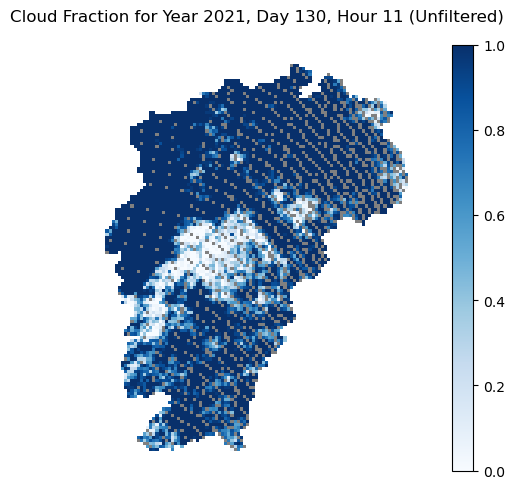

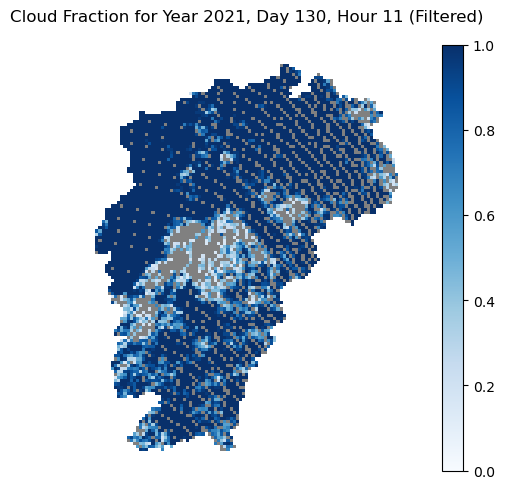

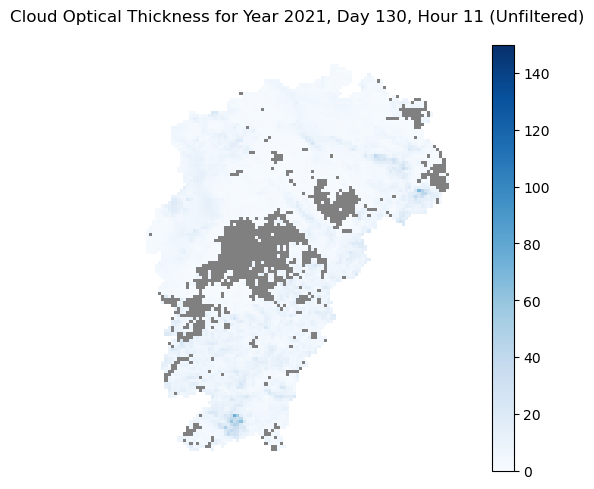

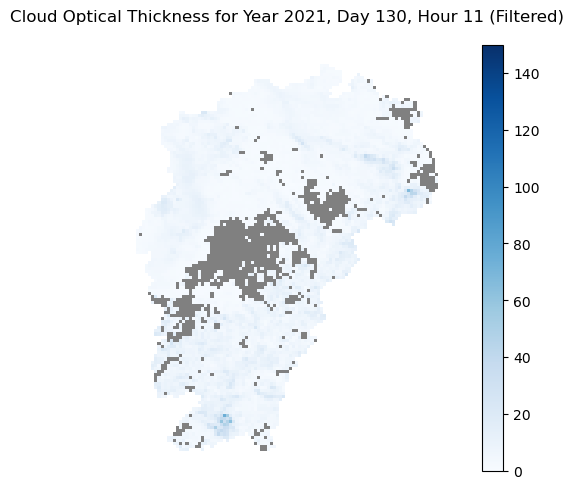

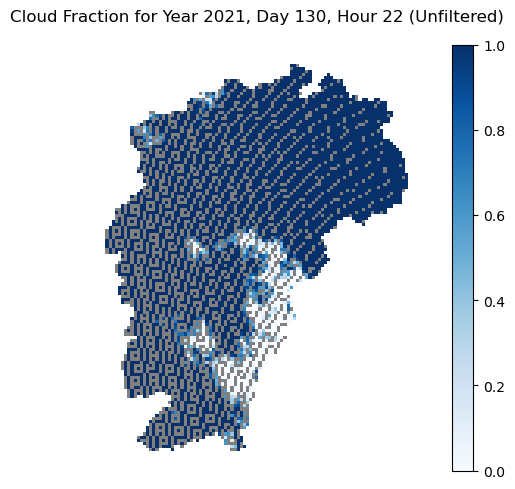

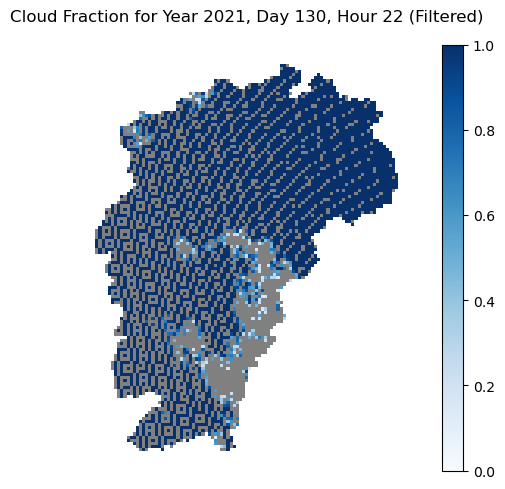

In [23]:
# Pick a random day to investigate
n = random.randint(1, 365)
data_f_day = data_f[data_f['day_of_year'] == n]
data_u_day = data_u[data_u['day_of_year'] == n]

# Plot the data for each hour
for hour in range(0,24):

    ## Convert the hour data to a geopandas object
    # unfiltered
    data_u_day_hour = data_u_day[data_u_day['hour'] == hour]
    plot_data_u = data_u_day_hour.merge(grid, how='left', on='cell_id')
    plot_data_u = gpd.GeoDataFrame(plot_data_u, geometry='geometry')

    # filtered
    data_f_day_hour = data_f_day[data_f_day['hour'] == hour]
    plot_data_f = data_f_day_hour.merge(grid, how='left', on='cell_id')
    plot_data_f = gpd.GeoDataFrame(plot_data_f, geometry='geometry')

    ## Plot cloud fraction
    # Split into NaN and non-NaN
    fraction_nan_mask_u = plot_data_u['cloud_fraction'].isna()
    fraction_nan_mask_f = plot_data_f['cloud_fraction'].isna()

    # Plot cloud fraction plot if there are > 0 solid cells in unfiltered data
    if len(plot_data_u[~fraction_nan_mask_u]) > 0:

        ## Unfiltered cloud fraction graph
        # Set axis
        fig_fraction_u, ax_fraction_u = plt.subplots(1, 1, figsize=(6, 5))

        # Plot NaN cells in grey first
        plot_data_u[fraction_nan_mask_u].plot(ax=ax_fraction_u, color='grey', linewidth=0.5)

        # Set legend between 0-1
        norm = mcolors.Normalize(vmin=0, vmax=1)

        # Plot non-NaN cells with a colormap
        plot_data_u[~fraction_nan_mask_u].plot(
            ax=ax_fraction_u,
            column='cloud_fraction',
            cmap='Blues',
            linewidth=0.5,
            legend=True,
            norm=norm
        )
        ax_fraction_u.set_title(f'Cloud Fraction for Year {year}, Day {n}, Hour {hour} (Unfiltered)')
        ax_fraction_u.set_axis_off()
        fig_fraction_u.savefig(f"{data_dir}/check/fraction_{year}_{n}_{hour}_unfiltered", dpi=300, bbox_inches='tight')
        
        plt.tight_layout()
        plt.show()
        plt.close(fig_fraction_u)

        ## Filtered cloud fraction graph
        # Set axis
        fig_fraction_f, ax_fraction_f = plt.subplots(1, 1, figsize=(6, 5))

        # Plot NaN cells in grey first
        plot_data_f[fraction_nan_mask_f].plot(ax=ax_fraction_f, color='grey', linewidth=0.5)

        # Set legend between 0-1
        norm = mcolors.Normalize(vmin=0, vmax=1)

        # Plot non-NaN cells with a colormap
        plot_data_f[~fraction_nan_mask_f].plot(
            ax=ax_fraction_f,
            column='cloud_fraction',
            cmap='Blues',
            linewidth=0.5,
            legend=True,
            norm=norm
        )

        ax_fraction_f.set_title(f'Cloud Fraction for Year {year}, Day {n}, Hour {hour} (Filtered)')
        ax_fraction_f.set_axis_off()
        fig_fraction_f.savefig(f"{data_dir}/check/fraction_{year}_{n}_{hour}_filtered", dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        plt.close(fig_fraction_f)
    
    
    ## Plot cloud optical thickness
    # Split into NaN and non-NaN
    thickness_nan_mask_u = plot_data_u['cloud_optical_thickness'].isna()
    thickness_nan_mask_f = plot_data_f['cloud_optical_thickness'].isna()

    # Plot cloud thickness plot if there are > 0 solid cells in unfiltered data
    if len(plot_data_u[~thickness_nan_mask_u]) > 0:

        ## Unfiltered cloud thickness graph
        # Set axis
        fig_thickness_u, ax_thickness_u = plt.subplots(1, 1, figsize=(6, 5))

        # Plot NaN cells in grey first
        plot_data_u[thickness_nan_mask_u].plot(ax=ax_thickness_u, color='grey', linewidth=0.5)

        # Set legend between 0-150
        norm = mcolors.Normalize(vmin=0, vmax=150)

        # Plot non-NaN cells with a colormap
        plot_data_u[~thickness_nan_mask_u].plot(
            ax=ax_thickness_u,
            column='cloud_optical_thickness',
            cmap='Blues',
            linewidth=0.5,
            legend=True,
            norm=norm
        )

        ax_thickness_u.set_title(f'Cloud Optical Thickness for Year {year}, Day {n}, Hour {hour} (Unfiltered)')
        ax_thickness_u.set_axis_off()
        fig_thickness_u.savefig(f"{data_dir}/check/thickness_{year}_{n}_{hour}_unfiltered", dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        plt.close(fig_thickness_u)

        ## Filtered cloud thickness graph
        # Set axis
        fig_thickness_f, ax_thickness_f = plt.subplots(1, 1, figsize=(6, 5))

        # Plot NaN cells in grey first
        plot_data_f[thickness_nan_mask_f].plot(ax=ax_thickness_f, color='grey', linewidth=0.5)

        # Set legend between 0-150
        norm = mcolors.Normalize(vmin=0, vmax=150)

        # Plot non-NaN cells with a colormap
        plot_data_f[~thickness_nan_mask_f].plot(
            ax=ax_thickness_f,
            column='cloud_optical_thickness',
            cmap='Blues',
            linewidth=0.5,
            legend=True,
            norm=norm
        )

        ax_thickness_f.set_title(f'Cloud Optical Thickness for Year {year}, Day {n}, Hour {hour} (Filtered)')
        ax_thickness_f.set_axis_off()
        fig_thickness_f.savefig(f"{data_dir}/check/thickness_{year}_{n}_{hour}_filtered", dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()
        plt.close(fig_thickness_f)


In [ ]:
### Check why the unfiltered and filtered cloud optical thickness graph is the same

# Helper to extract bits from a byte column
def extract_bits(df, column, start, end):
    def _extract(x):
        if pd.isna(x):
            return pd.NA
        bin_str = format(int(x), '08b')
        return int(bin_str[-(end+1):8-start], 2)
    
    return df[column].apply(_extract)

# Read cloud data
modis_dir = f"{data_dir}/intermediate/modis"
year = 2022
all_files = glob.glob(os.path.join(modis_dir, '*.csv'))
files_1km = [f for f in all_files if os.path.basename(f).startswith(f'1km_{year}')]
df_1km = pd.concat([pd.read_csv(f, index_col=0) for f in sorted(files_1km)], ignore_index=True)
df_1km['usefulness_flag'] = extract_bits(df_1km, 'qa1_byte_0', 0, 0)           # Byte 0, Bit 0
print(df_1km['usefulness_flag'].value_counts())

print(df_1km[df_1km['usefulness_flag'] == 1]['cloud_optical_thickness'].isna().mean())
print(df_1km[df_1km['usefulness_flag'] == 0]['cloud_optical_thickness'].isna().mean())

from pyhdf.SD import SD, SDC
import numpy as np

cp = "/Users/anora/Team MG Dropbox/Wanru Wu/Energy_Flux/modis_l2/MOD06_L2/MOD06_L2.A2022001.0000.061.2022001134419.hdf"
hdf = SD(cp, SDC.READ)

# Raw optical thickness
cot_raw = hdf.select('Cloud_Optical_Thickness')[:]
fill_val = hdf.select('Cloud_Optical_Thickness').attributes()['_FillValue']
is_fillvalue = (cot_raw == fill_val).flatten()

# Raw QA flag (bit 0 of byte 0)
qa1_raw = hdf.select('Quality_Assurance_1km')[:].astype('uint8')
usefulness_flag = (qa1_raw[:, :, 0] & 0b00000001).flatten()  # bit 0
is_flag_zero = (usefulness_flag == 0)

# Check overlap
print("fill value pixels:   ", is_fillvalue.sum())
print("flag==0 pixels:      ", is_flag_zero.sum())
print("both:                ", (is_fillvalue & is_flag_zero).sum())
print("flag==0 but NOT fill:", (is_flag_zero & ~is_fillvalue).sum())  # key check
print("fill but NOT flag==0:", (is_fillvalue & ~is_flag_zero).sum())  # key check

hdf.end()


usefulness_flag
0    46753800
1    22810283
Name: count, dtype: int64


In [ ]:
### Statistics

#1. In filtered and unfiltered version, how much portion have cloud fraction below 20%
#2. In filtered and unfiltered version, how much overall percent is cloud clear?
#3. In unfiltered version, how much of the clear cloud (>=20%) is marked as useful 

# Helper to extract bits from a byte column
def extract_bits(df, column, start, end):
    def _extract(x):
        if pd.isna(x):
            return pd.NA
        bin_str = format(int(x), '08b')
        return int(bin_str[-(end+1):8-start], 2)
    
    return df[column].apply(_extract)

# Read cloud data
modis_dir = f"{data_dir}/intermediate/modis"

all_files = glob.glob(os.path.join(modis_dir, '*.csv'))
for year in range(2020,2023):
    
    files_5km = [f for f in all_files if os.path.basename(f).startswith(f'5km_{year}')]
    df_5km = pd.concat([pd.read_csv(f, index_col=0) for f in sorted(files_5km)], ignore_index=True)

    # Convert to numerical data and handle NaN
    byte_cols = [col for col in df_5km.columns if col.startswith('qa5_byte_')]
    for col in byte_cols:
        df_5km[col] = pd.to_numeric(df_5km[col], errors='coerce')

    ##### Unfiltered Version

    # In unfiltered data, how much portion have cloud fraction below 20%
    df_5km_fraction_l20_portion = np.array(df_5km['cloud_fraction']<0.2).sum()/np.array(~pd.isna(df_5km['cloud_fraction'])).sum()
    print(f"In {year}, in unfiltered data, {df_5km_fraction_l20_portion} percent of cloud fraction is below 20%")

    # In unfiltered version, how much overall percent is cloud clear?
    df_5km['cloudy_flag'] = extract_bits(df_5km, "qa5_byte_3", 0, 7)
    df_5km['clear_flag'] = extract_bits(df_5km, "qa5_byte_4", 0, 7)
    df_5km['missing_flag'] = extract_bits(df_5km, "qa5_byte_5", 0, 7)

    cloudy_pixels = df_5km['cloudy_flag'].sum()
    clear_pixels = df_5km['clear_flag'].sum()
    missing_pixels = df_5km['missing_flag'].sum()
    sum_pixels = cloudy_pixels+clear_pixels+missing_pixels
    print(f"In {year}, in unfiltered data, {cloudy_pixels/sum_pixels} cloudy 1*1km pixels, {clear_pixels/sum_pixels} clear 1*1km pixels, and {missing_pixels/sum_pixels} missing 1*1km pixels")
    
    # In unfiltered version, how much of the clear cloud is marked as useful 
    df_5km_clear = df_5km[df_5km['clear_flag']>=20].copy()
    df_5km_clear['usefulness_flag'] = extract_bits(df_5km_clear, "qa5_byte_1", 0, 0)
    df_5km_clear_fraction_l20_portion = np.array(df_5km_clear['usefulness_flag']==1).sum()/len(df_5km_clear)
    print(f"In {year}, in unfiltered data, {df_5km_clear_fraction_l20_portion} of low cloud points (>=80% clear 1*1km pixels per 5*5km point) is marked as useful")

    ##### Filtered Version
    df_5km['usefulness_flag'] = extract_bits(df_5km, "qa5_byte_1", 0, 0)
    df_5km_f = df_5km[df_5km['usefulness_flag']==1].copy()

    # In filtered data, how much portion have cloud fraction below 20%
    df_5km_fraction_l20_portion = np.array(df_5km_f['cloud_fraction']<0.2).sum()/np.array(~pd.isna(df_5km_f['cloud_fraction'])).sum()
    print(f"In {year}, in useful data, {df_5km_fraction_l20_portion} percent of cloud fraction is below 20%")

    # Portion of filtered data with valid cloud_fraction that is low-cloud.
    df_5km_f_clear_portion = np.array((df_5km_f['clear_flag']>=20) & (~pd.isna(df_5km_f['cloud_fraction']))).sum()/np.array(~pd.isna(df_5km_f['cloud_fraction'])).sum()
    print(f"In {year}, in useful data, {df_5km_f_clear_portion} percent data is low cloud")





In 2020, in unfiltered data, 0.18923783664374685 percent of cloud fraction is below 20%
In 2020, in unfiltered data, 0.7720651614651624 cloudy 1*1km pixels, 0.22793358615226675 clear 1*1km pixels, and 1.2523825708700684e-06 missing 1*1km pixels
In 2020, in unfiltered data, 0.07415707202826642 of low cloud points (>=80% clear 1*1km pixels per 5*5km point) is marked as useful
In 2020, in useful data, 0.01701430730355348 percent of cloud fraction is below 20%
In 2020, in useful data, 0.01701430730355348 percent data is low cloud
In 2021, in unfiltered data, 0.25087681367474784 percent of cloud fraction is below 20%
In 2021, in unfiltered data, 0.7083967386964923 cloudy 1*1km pixels, 0.2903283729655908 clear 1*1km pixels, and 0.0012748883379169232 missing 1*1km pixels
In 2021, in unfiltered data, 0.06131797058799079 of low cloud points (>=80% clear 1*1km pixels per 5*5km point) is marked as useful
In 2021, in useful data, 0.020121814818923674 percent of cloud fraction is below 20%
In 2021,